Import Libraries

In [7]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

Load Dataset

In [8]:
df = pd.read_csv("../data/processed/marketing_campaign_feature_engineered.csv")

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp2,Complain,Response,Age,Customer_Tenure,Family_Size,Total_Spending,Total_Purchases,Accepted_Campaigns,Children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,1,69,4867,1,1617,22,0,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,72,4317,3,27,4,0,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,0,61,4516,1,776,20,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,0,42,4343,2,53,6,0,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,0,45,4365,2,422,14,0,1


Encode Categorical Columns

In [9]:
categorical_cols = ["Education", "Marital_Status"]

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

Drop Unnecessary Columns

In [10]:
X = df.drop(columns=["ID", "Dt_Customer", "Response"])

y = df["Response"]

Train-Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Scale the features

In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Logistic Regression (Baseline)

In [14]:
lr = LogisticRegression(
    max_iter=5000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]

Random Forest

In [15]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]

XGBoost

In [16]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:,1]

Evaluation Function

In [17]:
def evaluate(y_true, pred, prob):
    return {
        "Accuracy": accuracy_score(y_true, pred),
        "Precision": precision_score(y_true, pred),
        "Recall": recall_score(y_true, pred),
        "F1": f1_score(y_true, pred),
        "ROC_AUC": roc_auc_score(y_true, prob)
    }

Compare Models

In [18]:
results = pd.DataFrame([
    evaluate(y_test, lr_pred, lr_prob),
    evaluate(y_test, rf_pred, rf_prob),
    evaluate(y_test, xgb_pred, xgb_prob)
],
index=[
    "Logistic Regression",
    "Random Forest",
    "XGBoost"
])

results

,Accuracy,Precision,Recall,F1,ROC_AUC
Logistic Regression,0.883929,0.741935,0.343284,0.469388,0.877013
Random Forest,0.886161,0.785714,0.328358,0.463158,0.878442
XGBoost,0.890625,0.750000,0.402985,0.524272,0.903416


Best Model

In [19]:
results.sort_values("ROC_AUC", ascending=False)

,Accuracy,Precision,Recall,F1,ROC_AUC
XGBoost,0.890625,0.750000,0.402985,0.524272,0.903416
Random Forest,0.886161,0.785714,0.328358,0.463158,0.878442
Logistic Regression,0.883929,0.741935,0.343284,0.469388,0.877013


Feature Importance (Random Forest)

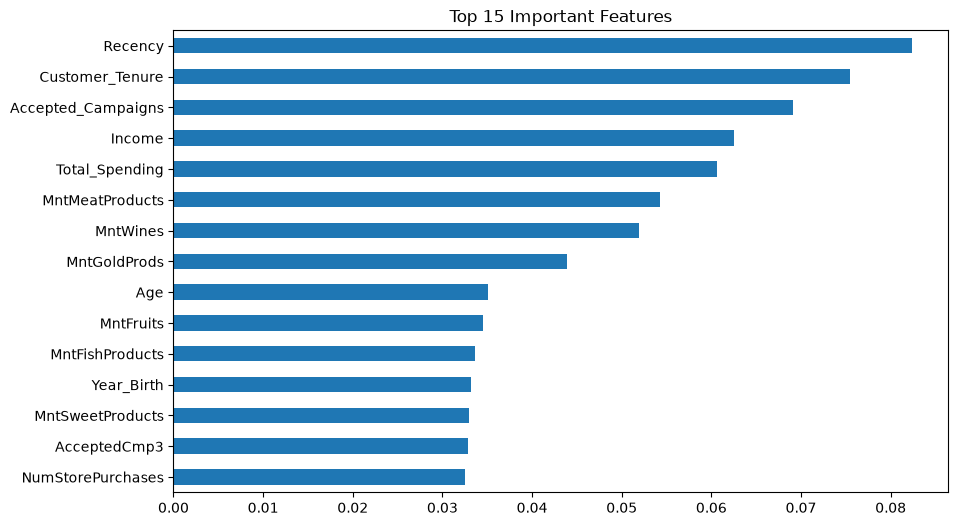

In [20]:
import matplotlib.pyplot as plt

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))

importance.head(15).plot(kind="barh")

plt.title("Top 15 Important Features")

plt.gca().invert_yaxis()

plt.show()

Confusion Matrix

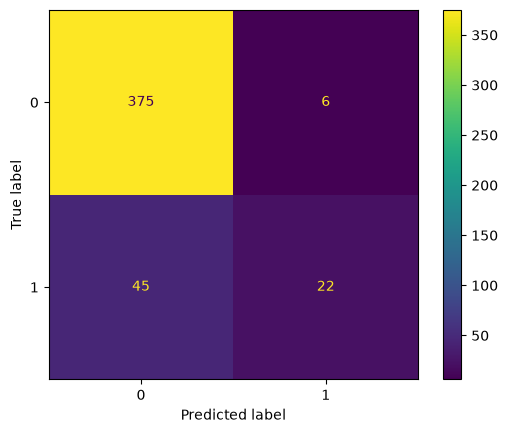

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test
)

plt.show()